* Seeting up a virtual environment is needed, the codes are in the following:


conda create -n econml-py39 python=3.9
conda activate econml-py39
pip install numpy==1.23.5 scipy==1.10.1 pandas==1.5.3 scikit-learn==1.2.2 matplotlib==3.6.3 seaborn==0.12.2 xgboost==1.7.5 lightgbm==3.3.5 shap==0.43.0 econml==0.15.0

pip install ipykernel
python -m ipykernel install --user --name econml-py39 --display-name econml-py39


* Varialbes get from WRDS

(fyear) Data Year - Fiscal
(derhedgl) Gains/Losses on Derivatives and Hedging
(dvt) Dividends - Total
(at) Assets - Total
(dt) Total Debt Including Current
(mkvalt) Market Value - Total - Fiscal
(ni) Net Income (Loss)
(capx) Capital Expenditures
(prcc_f) Price Close - Annual - Fiscal
(csho) Common Shares Outstanding
(seq) Stockholders Equity - Parent
(pstkrv) Preferred Stock - Redemption Value
(pstkr) Preferred/Preference Stock – Redeemable
(lt) Liabilities – Total
Act Current Assets
Lct Current Liabilities


In [1]:
from econml.grf import CausalForest
import numpy as np
import scipy.special
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from docx import Document
from docx.shared import Inches
import scipy.stats as stats
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
#from seaborn import sns

In [136]:
df = pd.read_csv('data_raw.csv')
df['derhedgl_binary'] = df['derhedgl'].apply(lambda x: 0 if pd.isna(x) else 1) #dummy for derivative use
df['dividend_binary'] = df['dvt'].apply(lambda x: 0 if pd.isna(x) else 1)
# Filtering data by total assets,total debt, market value. If there was any 0 value during the research period, the company(gvkey) is delated
df = df[df['fyear'] >= 2013] #due to data availbility, I will use the period from 2013 to 2023 
to_exclude = df[(df['at'] == 0) | (df['dt'] == 0) | (df['mkvalt'] == 0 )|(df['ni'] == 0)|(df['capx']==0)|(df['lct']==0)|
                (df['seq']==0)
                  ].gvkey.unique()
filtered_data = df[~df['gvkey'].isin(to_exclude)]
filtered_data = filtered_data.dropna(subset= ['dt','mkvalt','capx','at','ni','lct','seq'])
filtered_data.isna().sum()
filtered_len = len(filtered_data)
filtered_data['derhedgl_binary'].describe()
filtered_data['ln_mkvalt'] = np.log(filtered_data['mkvalt'])

filtered_data['ln_at'] = np.log(filtered_data['at']) 
filtered_data['ln_dt'] = np.log(filtered_data['dt'])
filtered_data['ln_mkvalt'] = np.log(filtered_data['mkvalt'])
filtered_data['current_ratio'] = filtered_data['act']/ filtered_data['lct']
filtered_data['growth'] = filtered_data['capx']/filtered_data['at']
#filtered_data['debt_to_equity'] = filtered_data['ln_dt'] / (filtered_data['ln_at'] - filtered_data['ln_dt']) 
filtered_data['debt_to_equity'] = filtered_data['dt'] / (filtered_data['at'] - filtered_data['dt']) 
filtered_data['tobins_q'] = (filtered_data['mkvalt']) / filtered_data['at']
filtered_data['ROA'] = filtered_data['ni']/filtered_data['at']
filtered_data['leverage'] = filtered_data['dt']/filtered_data['at']
filtered_data['mb'] = filtered_data['csho'] * filtered_data['prcc_f']/(filtered_data['seq'] )
filtered_data = filtered_data.sort_values(by=['gvkey', 'fyear'])
filtered_data['l_derhedgl_binary'] = filtered_data.groupby('gvkey')['derhedgl_binary'].shift(1)





#filtered_data['sic_group'] = filtered_data['sic'].astype(str).str[:1]
#sic_group_dummies = pd.get_dummies(filtered_data['sic_group'], prefix='sic_group')
#filtered_data = pd.concat([filtered_data, sic_group_dummies], axis=1)
print(len(filtered_data))
filtered_data.isna().sum()
filtered_data['ln_tobins_q'] = np.log(filtered_data['tobins_q'])







28725


In [137]:
winsor_vars = ['debt_to_equity',  'tobins_q', 'ROA', 'leverage','growth' ,
               'current_ratio', 'ln_mkvalt','ln_tobins_q','derhedgl','mb']

def winsorize_series(series, lower_percent=1, upper_percent=99):
    lower_bound = series.quantile(lower_percent/100)
    upper_bound = series.quantile(upper_percent/100)
    return series.clip(lower_bound, upper_bound)

for var in winsor_vars:
    if var in filtered_data.columns:
        orig_min = filtered_data[var].min()
        orig_max = filtered_data[var].max()
        orig_mean = filtered_data[var].mean()
        
        # apply winsorize
        filtered_data[var] = winsorize_series(filtered_data[var])
        
        # get outcome
        win_min = filtered_data[var].min()
        win_max = filtered_data[var].max()
        win_mean = filtered_data[var].mean()
        
        print(f"{var}:")
        print(f"  Original range: [{orig_min:.4f}, {orig_max:.4f}]")
        print(f"  New range: [{win_min:.4f}, {win_max:.4f}]")
        print(f"  Changes in MeanValue: {orig_mean:.4f} → {win_mean:.4f}")
        print()
filtered_data.to_csv('filtered_data.csv', index=False)


debt_to_equity:
  Original range: [-20545.0000, 1820.0000]
  New range: [-5.4182, 8.4458]
  Changes in MeanValue: -0.1239 → 0.6048

tobins_q:
  Original range: [0.0000, 52518.9000]
  New range: [0.0376, 10.3885]
  Changes in MeanValue: 4.7174 → 1.4136

ROA:
  Original range: [-3267.6667, 7.8058]
  New range: [-2.0024, 0.2840]
  Changes in MeanValue: -0.2411 → -0.0705

leverage:
  Original range: [0.0000, 833.3333]
  New range: [0.0013, 1.5491]
  Changes in MeanValue: 0.3855 → 0.3366

growth:
  Original range: [-0.0451, 63.3333]
  New range: [0.0005, 0.3343]
  Changes in MeanValue: 0.0534 → 0.0488

current_ratio:
  Original range: [0.0000, 130.6307]
  New range: [0.1126, 14.1141]
  Changes in MeanValue: 2.3349 → 2.2115

ln_mkvalt:
  Original range: [-7.6009, 14.7947]
  New range: [0.9560, 11.9419]
  Changes in MeanValue: 6.7206 → 6.7242

ln_tobins_q:
  Original range: [-15.2370, 10.8689]
  New range: [-3.2801, 2.3407]
  Changes in MeanValue: -0.1743 → -0.1705

derhedgl:
  Original range

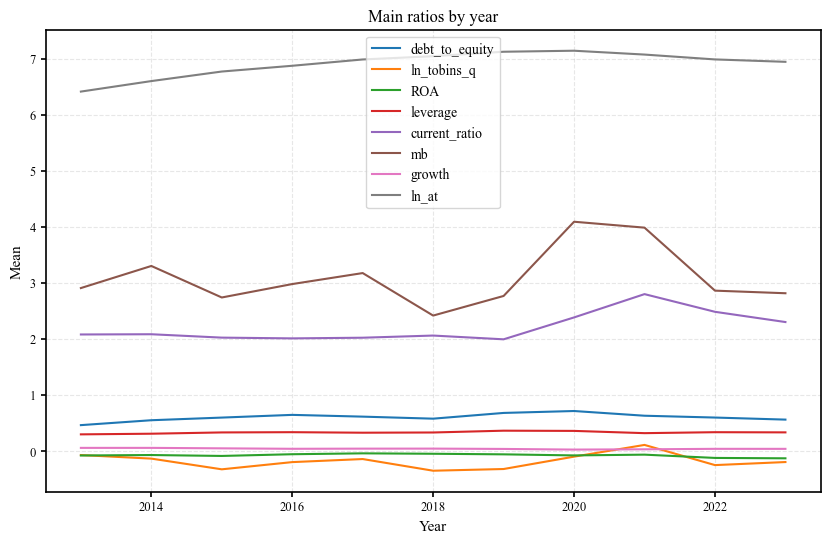

In [139]:
mean_by_year = filtered_data.groupby('fyear').mean(numeric_only=True)
mean_by_year.describe()
mean_by_year[['debt_to_equity',  'ln_tobins_q', 'ROA', 'leverage', 
               'current_ratio', 'mb','growth','ln_at']].plot(figsize=(10,6))
plt.title('Main ratios by year')
plt.ylabel('Mean')
plt.xlabel('Year')
plt.show()

In [142]:

years_comparison = []
for year in [2020, 2021, 2022, 2023]:
    year_data = filtered_data[filtered_data['fyear'] == year]
    equity = year_data['at'] - year_data['dt']
    at_trend= year_data['at']
    years_comparison.append({
        'year': year,
        'median_equity': equity.median(),
        'neg_equity_pct': (equity <= 0).mean() * 100,
        'low_equity_pct': ((equity > -1) & (equity < 1)).mean() * 100,
        'de_mean': year_data['debt_to_equity'].mean(),
        'de_median': year_data['debt_to_equity'].median(),
        'at_mean': year_data['at'].mean(),
        'at_neg': (at_trend <= 0).mean() * 100,
    })
  
comparison_df = pd.DataFrame(years_comparison)

print(comparison_df.to_string())

   year  median_equity  neg_equity_pct  low_equity_pct   de_mean  de_median      at_mean  at_neg
0  2020        887.600        2.361529        0.214684  0.720401   0.471051  9010.233119     0.0
1  2021        771.621        1.904406        0.336072  0.636364   0.394687  8838.925961     0.0
2  2022        752.399        3.240059        0.478645  0.603838   0.397561  8617.352032     0.0
3  2023        755.800        3.339518        0.630798  0.567156   0.386054  9105.806934     0.0


In [22]:
#User, Non-User comparison table. Annual Distribution of Derivatives Users (2013-2023)

yearly_stats = filtered_data.groupby('fyear').agg(
    N=('gvkey', 'count'),  
    Users=('derhedgl_binary', lambda x: (x == 1).sum()),  
    Non_users=('derhedgl_binary', lambda x: (x == 0).sum())  
).reset_index()

yearly_stats['% users'] = (yearly_stats['Users'] / yearly_stats['N'] * 100).round(2)
yearly_stats['% non-users'] = (yearly_stats['Non_users'] / yearly_stats['N'] * 100).round(2)

yearly_stats = yearly_stats.sort_values('fyear')

full_years = pd.DataFrame({'fyear': range(2013, 2024)})
yearly_stats = pd.merge(full_years, yearly_stats, on='fyear', how='left')
yearly_stats = yearly_stats.rename(columns={
    'fyear': 'Year',
    'Non_users': 'Non-users',
    '% users': '% users',
    '% non-users': '% non-users'
})

print(yearly_stats.to_string(index=False))
yearly_stats.to_csv('derivative_usage_by_year.csv',index = False)


 Year    N  Users  Non-users  % users  % non-users
 2013 3136   1045       2091    33.32        66.68
 2014 3059   1082       1977    35.37        64.63
 2015 2889   1021       1868    35.34        64.66
 2016 2717    943       1774    34.71        65.29
 2017 2620    876       1744    33.44        66.56
 2018 2597    868       1729    33.42        66.58
 2019 2523    820       1703    32.50        67.50
 2020 2474    785       1689    31.73        68.27
 2021 2833    935       1898    33.00        67.00
 2022 2875    977       1898    33.98        66.02
 2023 2850    965       1885    33.86        66.14


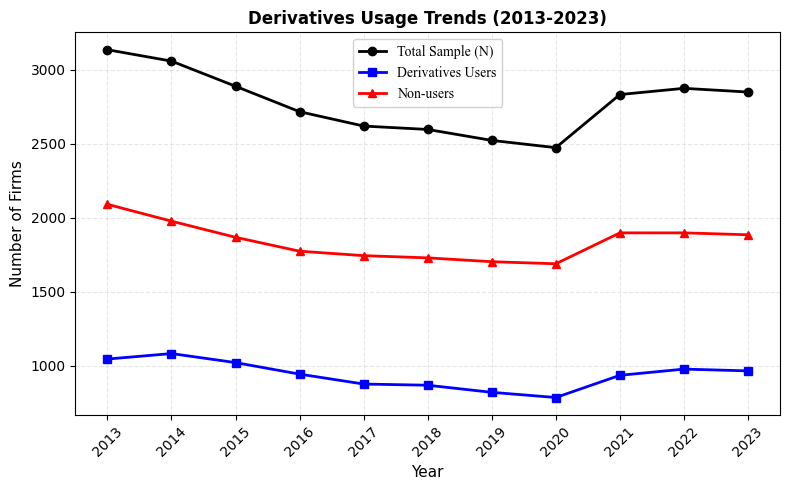

In [23]:
# Plot for user and non users fig:derivatives_trend

fig, ax = plt.subplots(figsize=(8, 5))
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})


ax.plot(yearly_stats['Year'], yearly_stats['N'], 
        'ko-', label='Total Sample (N)', linewidth=2, markersize=6)
ax.plot(yearly_stats['Year'], yearly_stats['Users'], 
        'bs-', label='Derivatives Users', linewidth=2, markersize=6)
ax.plot(yearly_stats['Year'], yearly_stats['Non-users'], 
        'r^-', label='Non-users', linewidth=2, markersize=6)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Number of Firms', fontsize=11)
ax.set_title('Derivatives Usage Trends (2013-2023)', fontsize=12, fontweight='bold')


ax.set_xticks(yearly_stats['Year'])
ax.set_xticklabels(yearly_stats['Year'], rotation=45)


ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(frameon=True, framealpha=0.9)


plt.tight_layout()


plt.savefig('derivatives_trend_simple.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [144]:
#Descriptive tab:desc_stats

def create_descriptive_stats_by_hedge(df, variables):
    
    results = []

    for var in variables:

        all_stats = {
            'Variable': var,
            'Group': 'All firms',
            'N': df[var].count(),
            'Mean': df[var].mean(),
            'Median': df[var].median(),
            'St. Dev.': df[var].std(),
            'Min': df[var].min(),
            'Max': df[var].max()
        }
        results.append(all_stats)
        
        non_users = df[df['derhedgl_binary'] == 0]
        non_stats = {
            'Variable': var,
            'Group': 'Non-users',
            'N': non_users[var].count(),
            'Mean': non_users[var].mean(),
            'Median': non_users[var].median(),
            'St. Dev.': non_users[var].std(),
            'Min': non_users[var].min(),
            'Max': non_users[var].max()
            
        }
        results.append(non_stats)

    
        users = df[df['derhedgl_binary'] == 1]
        user_stats = {
            'Variable': var,
            'Group': 'Users',
            'N': users[var].count(),
            'Mean': users[var].mean(),
            'Median': users[var].median(),
            'St. Dev.': users[var].std(),
            'Min': users[var].min(),
            'Max': users[var].max()
        }
        results.append(user_stats)

    results_df = pd.DataFrame(results)  

    for col in ['Mean', 'Median', 'St. Dev.', 'Min', 'Max']:
        results_df[col] = results_df[col].apply(lambda x: f"{x:,.4f}" if pd.notnull(x) else "")
    results_df['N'] = results_df['N'].astype(int)

    return results_df

assert 'derhedgl_binary' in filtered_data.columns
assert set(filtered_data['derhedgl_binary'].unique()).issubset({0, 1})


selected_variables = ['at','ln_at', 'dt', 'mkvalt', 'ROA', 'tobins_q','ln_tobins_q', 'leverage','debt_to_equity','current_ratio']  # Variables


descriptive_table = create_descriptive_stats_by_hedge(filtered_data, selected_variables)

for var in selected_variables:
    var_data = descriptive_table[descriptive_table['Variable'] == var]
    print(f"\nVariable: {var}")
    print("-" * 40)
    print(var_data[['Group', 'N', 'Mean', 'Median', 'St. Dev.','Min','Max']].to_string(index=False))


descriptive_table.to_csv('descriptive_stats_by_hedge.csv', index=False)




Variable: at
----------------------------------------
    Group     N        Mean     Median    St. Dev.    Min          Max
All firms 28725  7,574.0206 1,200.2630 25,529.0240 0.0010 551,669.0000
Non-users 18720  6,204.6709   952.2815 23,466.6946 0.0020 531,864.0000
    Users 10005 10,136.1622 1,794.7980 28,823.4845 0.0010 551,669.0000

Variable: ln_at
----------------------------------------
    Group     N   Mean Median St. Dev.     Min     Max
All firms 28725 6.8949 7.0903   2.2609 -6.9078 13.2207
Non-users 18720 6.6714 6.8589   2.2335 -6.2146 13.1841
    Users 10005 7.3131 7.4926   2.2526 -6.9078 13.2207

Variable: dt
----------------------------------------
    Group     N       Mean   Median   St. Dev.    Min          Max
All firms 28725 2,531.5718 338.7620 8,475.3540 0.0010 197,076.0000
Non-users 18720 2,089.4890 251.6350 7,650.7433 0.0010 177,930.0000
    Users 10005 3,358.7373 542.9020 9,781.1519 0.0010 197,076.0000

Variable: mkvalt
----------------------------------------
 

In [28]:
#filtering data with hdgl_binary=1 for further test
#if thereis na still using the following code to clean again
#filtered_data = filtered_data[(filtered_data['capx'] != 0) & (filtered_data['capx'].notna()) &
#(filtered_data['derhedgl'].notna()) &(filtered_data['ni'].notna())]

der_set = filtered_data[filtered_data['derhedgl_binary'] == 1]

print(der_set.describe())

der_set.to_csv('der_set.csv', index=False)


              fyear          gvkey         exchg           gind           sic  \
count  10317.000000   10317.000000  10317.000000   10314.000000  10317.000000   
mean    2017.859455   77903.751187     13.964815  276963.687221   3966.935543   
std        3.253569   76011.662626      3.209111  135587.937725   2083.600403   
min     2013.000000    1050.000000      1.000000  101010.000000    100.000000   
25%     2015.000000   15044.000000     11.000000  151040.000000   2810.000000   
50%     2018.000000   36952.000000     14.000000  252030.000000   3663.000000   
75%     2021.000000  160255.000000     19.000000  352020.000000   5047.000000   
max     2023.000000  351491.000000     19.000000  602010.000000   9997.000000   

           curuscn    aocidergl             at             lt       cidergl  \
count  1729.000000  9894.000000   10317.000000   10317.000000  10256.000000   
mean      0.792086    -3.535849   10266.726259    6675.795781     -0.118977   
std       0.068789    85.703132  

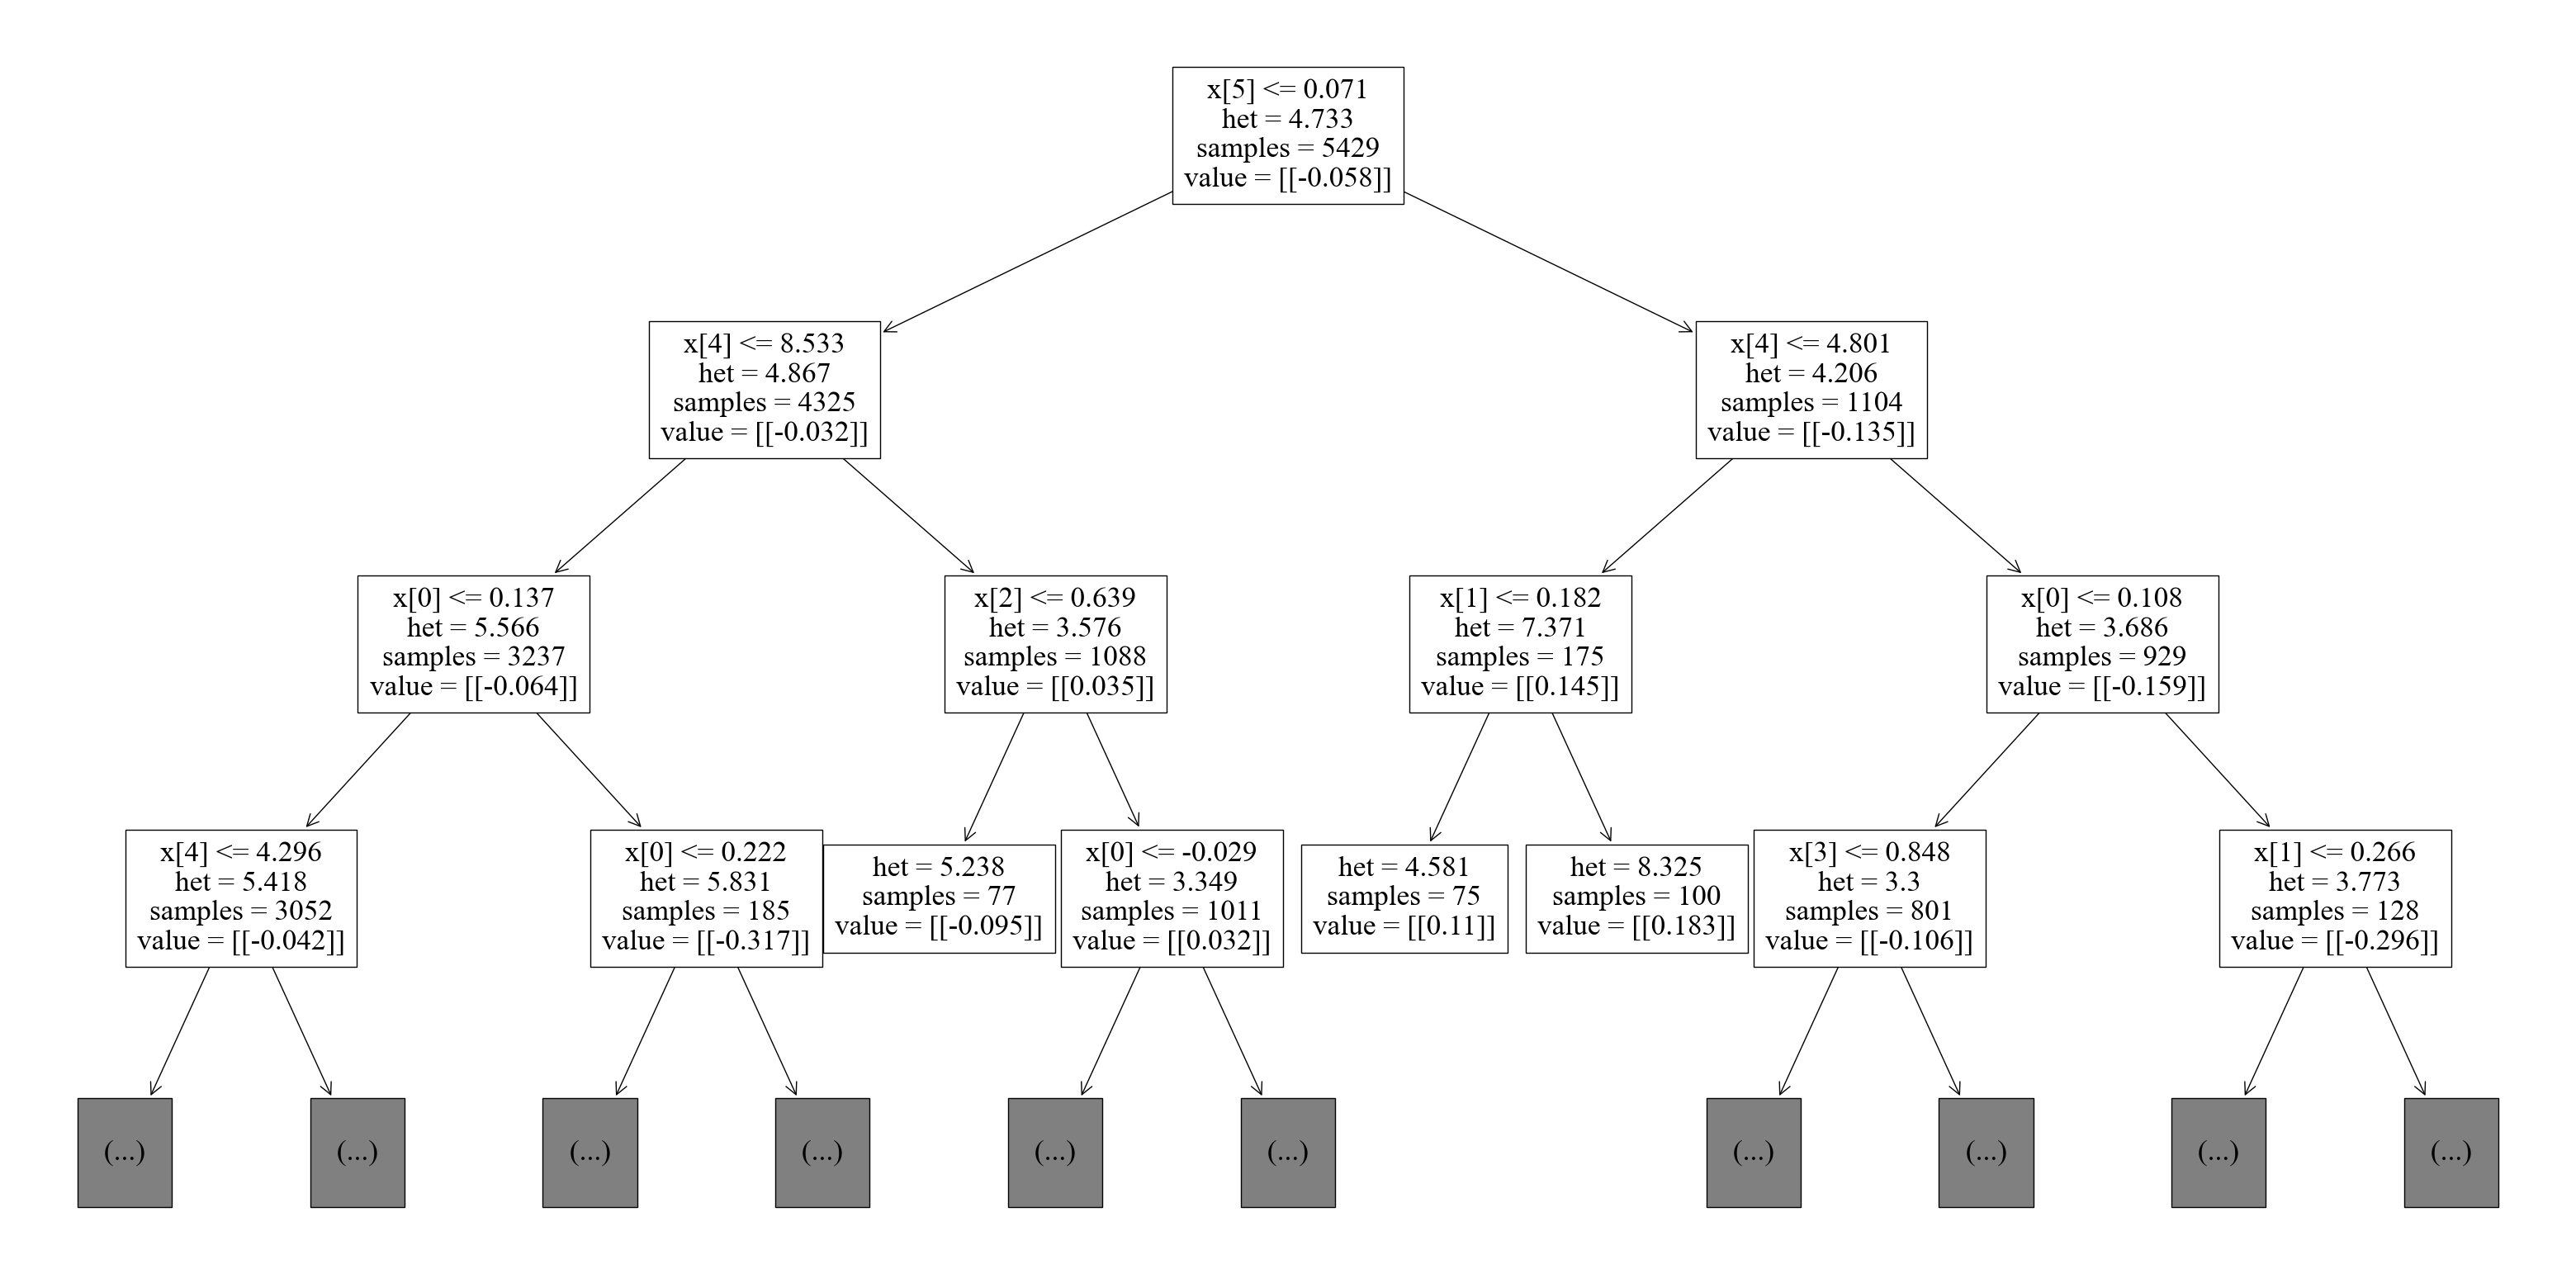

ATE: -0.0538
SE: 0.0008
95%confidentual: [-0.0553, -0.0523]


In [148]:
# First casual forest
causal_data = filtered_data[['ROA', 'leverage', 'current_ratio', 'debt_to_equity',
                            'ln_at', 'growth', 'dividend_binary',
                            'l_derhedgl_binary', 'ln_tobins_q']].dropna()

# 使用清理后的数据
X = causal_data[['ROA', 'leverage', 'current_ratio', 'debt_to_equity', 
                 'ln_at', 'growth', 'dividend_binary']].values
T = causal_data['l_derhedgl_binary'].values
y = causal_data['ln_tobins_q'].values.reshape(-1, 1)


# setting CausalForest， min leaf is 50 to prevent over-fitting
est = CausalForest(criterion='het', n_estimators=2000, min_samples_leaf=50, max_depth=20,
                   min_var_fraction_leaf=None, min_var_leaf_on_val=True,
                    max_samples=0.45, min_balancedness_tol=.45,
                   warm_start=False, inference=True, fit_intercept=True, subforest_size=4,
                   honest=True, verbose=0, n_jobs=-1, random_state=1235)


est.fit(X, T, y)

plt.figure(figsize=(40, 20))
plot_tree(est[0], impurity=True,  max_depth=3)
plt.show()

individual_effects = est.predict(X)

ate = np.mean(individual_effects)
ate_se = np.std(individual_effects) / np.sqrt(len(individual_effects))
print(f"ATE: {ate:.4f}")
print(f"SE: {ate_se:.4f}")
print(f"95%confidentual: [{ate - 1.96*ate_se:.4f}, {ate + 1.96*ate_se:.4f}]")

CATE from ATE: -0.0538


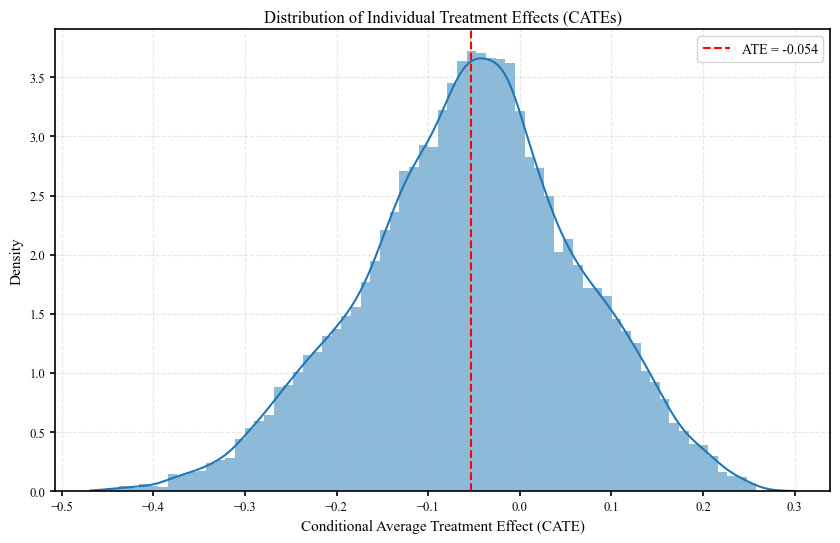

In [149]:
import seaborn as sns
cates = est.predict(X)
ate_value = np.mean(cates)
print (f"CATE from ATE: {ate_value:.4f}")
plt.figure(figsize=(10, 6))
sns.histplot(cates, kde=True, stat="density", linewidth=0)
plt.axvline(ate_value, color='red', linestyle='--', label=f'ATE = {ate_value:.3f}')
plt.xlabel('Conditional Average Treatment Effect (CATE)')
plt.ylabel('Density')
plt.title('Distribution of Individual Treatment Effects (CATEs)')
plt.legend()
plt.savefig('CF_tbq.pdf', dpi=300, bbox_inches='tight')
plt.show()
#\caption{Distribution of Individual Treatment Effects Derivatives Usage among Companies (2013-2023)} 

In [150]:
ite = est.predict(X).flatten()

# Add ITE back to original data
df_analysis = causal_data.copy()
df_analysis['ITE'] = ite

# ============ 2. Select top 20% ITE companies ============
top_percent = 0.20   # can adjust to 0.10 or 0.30
threshold = np.quantile(ite, 1 - top_percent)

df_high_ite = df_analysis[df_analysis['ITE'] >= threshold]

print("Number of high-ITE companies:", len(df_high_ite))

# ============ 3. Summarize feature means ============
feature_cols = ['ROA', 'leverage', 'current_ratio', 'debt_to_equity', 
                 'ln_at', 'growth', 'dividend_binary']

high_ite_profile = df_high_ite[feature_cols].describe()
overall_profile = df_analysis[feature_cols].describe()

print("\n=== High-ITE Company Profile (Top 20%) ===")
print(high_ite_profile)

print("\n=== Overall Company Profile ===")
print(overall_profile)

# ============ 4. Compare difference ============
diff = high_ite_profile.loc['mean'] - overall_profile.loc['mean']
print("\n=== Difference Between High-ITE and Overall (means) ===")
print(diff.sort_values(ascending=False))


Number of high-ITE companies: 4826

=== High-ITE Company Profile (Top 20%) ===
               ROA     leverage  current_ratio  debt_to_equity        ln_at  \
count  4826.000000  4826.000000    4826.000000     4826.000000  4826.000000   
mean     -0.116888     0.275166       2.690395        0.530384     6.062021   
std       0.341694     0.210717       2.074677        0.966258     2.863194   
min      -2.002434     0.001292       0.130258       -5.418169     0.330742   
25%      -0.155413     0.116014       1.450538        0.127327     3.820538   
50%       0.010133     0.239357       2.102387        0.309789     4.934805   
75%       0.057393     0.385523       3.086274        0.616634     8.941545   
max       0.283978     1.549138      14.114077        8.445838    12.688153   

            growth  dividend_binary  
count  4826.000000      4826.000000  
mean      0.020127         0.995856  
std       0.014646         0.064249  
min       0.000461         0.000000  
25%       0.010536 


Feature Importance Ranking
Rank  Feature              Importance %       
------------------------------------------------------------
1     growth               0.520      52.0    %
2     ln_at                0.208      20.8    %
3     current_ratio        0.122      12.2    %
4     ROA                  0.061      6.1     %
5     debt_to_equity       0.046      4.6     %
6     leverage             0.044      4.4     %
7     dividend_binary      0.000      0.0     %


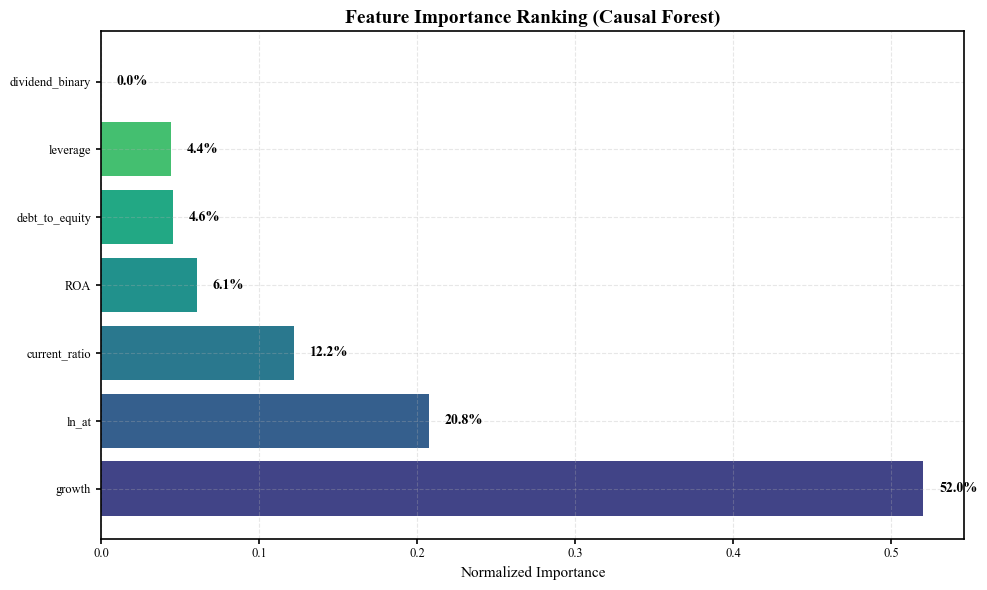


Results saved to: feature_importance_ranking.csv


In [151]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import cm
matplotlib.rcParams['text.usetex'] = False
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica']

# setting names
feature_names = ['ROA', 'leverage', 'current_ratio', 'debt_to_equity', 
                 'ln_at', 'growth', 'dividend_binary']

# get ranks
if hasattr(est, 'feature_importances_'):
    importance = est.feature_importances_
else:
    importance = np.ones(len(feature_names)) / len(feature_names)

# standerlize 
if importance.sum() > 0:
    importance_norm = importance / importance.sum()


df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Score': importance,
    'Normalized': importance_norm,
    'Percentage': importance_norm * 100
})

df = df.sort_values('Normalized', ascending=False)
df['Rank'] = range(1, len(df) + 1)


print("\n" + "="*60)
print("Feature Importance Ranking")
print("="*60)
print(f"{'Rank':<5} {'Feature':<20} {'Importance':<10} {'%':<8}")
print("-"*60)

for _, row in df.iterrows():
    print(f"{row['Rank']:<5} {row['Feature']:<20} {row['Normalized']:<10.3f} {row['Percentage']:<8.1f}%")

print("="*60)


plt.figure(figsize=(10, 6))
colors = cm.viridis(np.linspace(0.2, 0.8, len(df)))
bars = plt.barh(df['Feature'], df['Normalized'], color=colors)
plt.xlabel('Normalized Importance')
plt.title('Feature Importance Ranking (Causal Forest)', fontsize=14, fontweight='bold')

for bar, value in zip(bars, df['Normalized']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{value:.1%}', va='center', fontweight='bold')

plt.grid(True, axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Ranking_binanry.pdf')
plt.show()

#\caption{Feature Importance Ranking: Contribution to Heterogeneity in Causal Forest Model}
df.to_csv('feature_importance_ranking.csv', index=False)
print("\nResults saved to: feature_importance_ranking.csv")


In [152]:
# \caption{T-Test Results: High ITE vs Overall Sample} \label{tab:t_test_results}
from scipy.stats import ttest_ind
import pandas as pd
import numpy as np

# feature list
feature_cols = ['ROA', 'leverage', 'current_ratio', 'debt_to_equity', 
                 'ln_at', 'growth', 'dividend_binary']

results = []

for col in feature_cols:
    high_group = df_high_ite[col].dropna()
    overall_group = df_analysis[col].dropna()

    # Welch’s t-test (unequal variance)
    t_stat, p_val = ttest_ind(high_group, overall_group, equal_var=False)

    # effect direction (mean difference)
    mean_diff = high_group.mean() - overall_group.mean()

    # significance stars
    if p_val < 0.01:
        sig = "***"
    elif p_val < 0.05:
        sig = "**"
    elif p_val < 0.1:
        sig = "*"
    else:
        sig = ""

    results.append({
        "feature": col,
        "mean_high_ITE": high_group.mean(),
        "mean_overall": overall_group.mean(),
        "mean_diff": mean_diff,
        "t_stat": t_stat,
        "p_value": p_val,
        "significance": sig
    })

# Convert to DataFrame
ttest_df = pd.DataFrame(results)
ttest_df = ttest_df.sort_values("mean_diff", ascending=False)


print("\n=== T-test Results: High ITE vs Overall ===")
print(ttest_df)



=== T-test Results: High ITE vs Overall ===
           feature  mean_high_ITE  mean_overall  mean_diff     t_stat  \
2    current_ratio       2.690395      2.123835   0.566560  17.509921   
6  dividend_binary       0.995856      0.996228  -0.000373  -0.370462   
5           growth       0.020127      0.046996  -0.026869 -66.059740   
0              ROA      -0.116888     -0.057846  -0.059042 -11.194183   
1         leverage       0.275166      0.344361  -0.069195 -19.954201   
3   debt_to_equity       0.530384      0.631233  -0.100850  -6.111075   
4            ln_at       6.062021      7.034043  -0.972022 -22.280555   

         p_value significance  
2   3.877565e-67          ***  
6   7.110498e-01               
5   0.000000e+00          ***  
0   8.092105e-29          ***  
1   1.622593e-86          ***  
3   1.029562e-09          ***  
4  9.435905e-106          ***  


In [103]:
feature_names = ['ROA', 'leverage', 'current_ratio', 'debt_to_equity', 
                 'ln_at', 'growth', 'dividend_binary']

imp = est.feature_importances_

df_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": imp
}).sort_values("importance", ascending=False)

print(df_imp)



           feature  importance
5           growth    0.567553
4            ln_at    0.197979
2    current_ratio    0.092978
0              ROA    0.061311
1         leverage    0.041659
3   debt_to_equity    0.038521
6  dividend_binary    0.000000


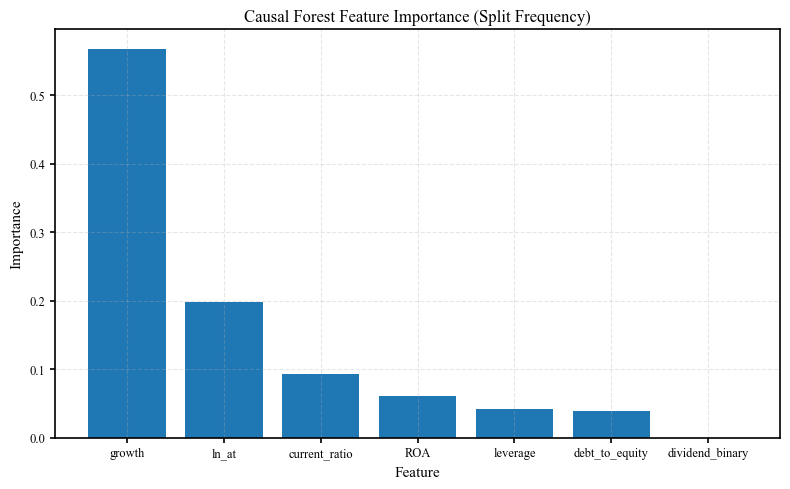

In [104]:
#Causal Forest Feature Importance (Split Frequency) figure
plt.figure(figsize=(8,5))
plt.bar(df_imp['feature'], df_imp['importance'])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Causal Forest Feature Importance (Split Frequency)")
plt.tight_layout()
plt.show()

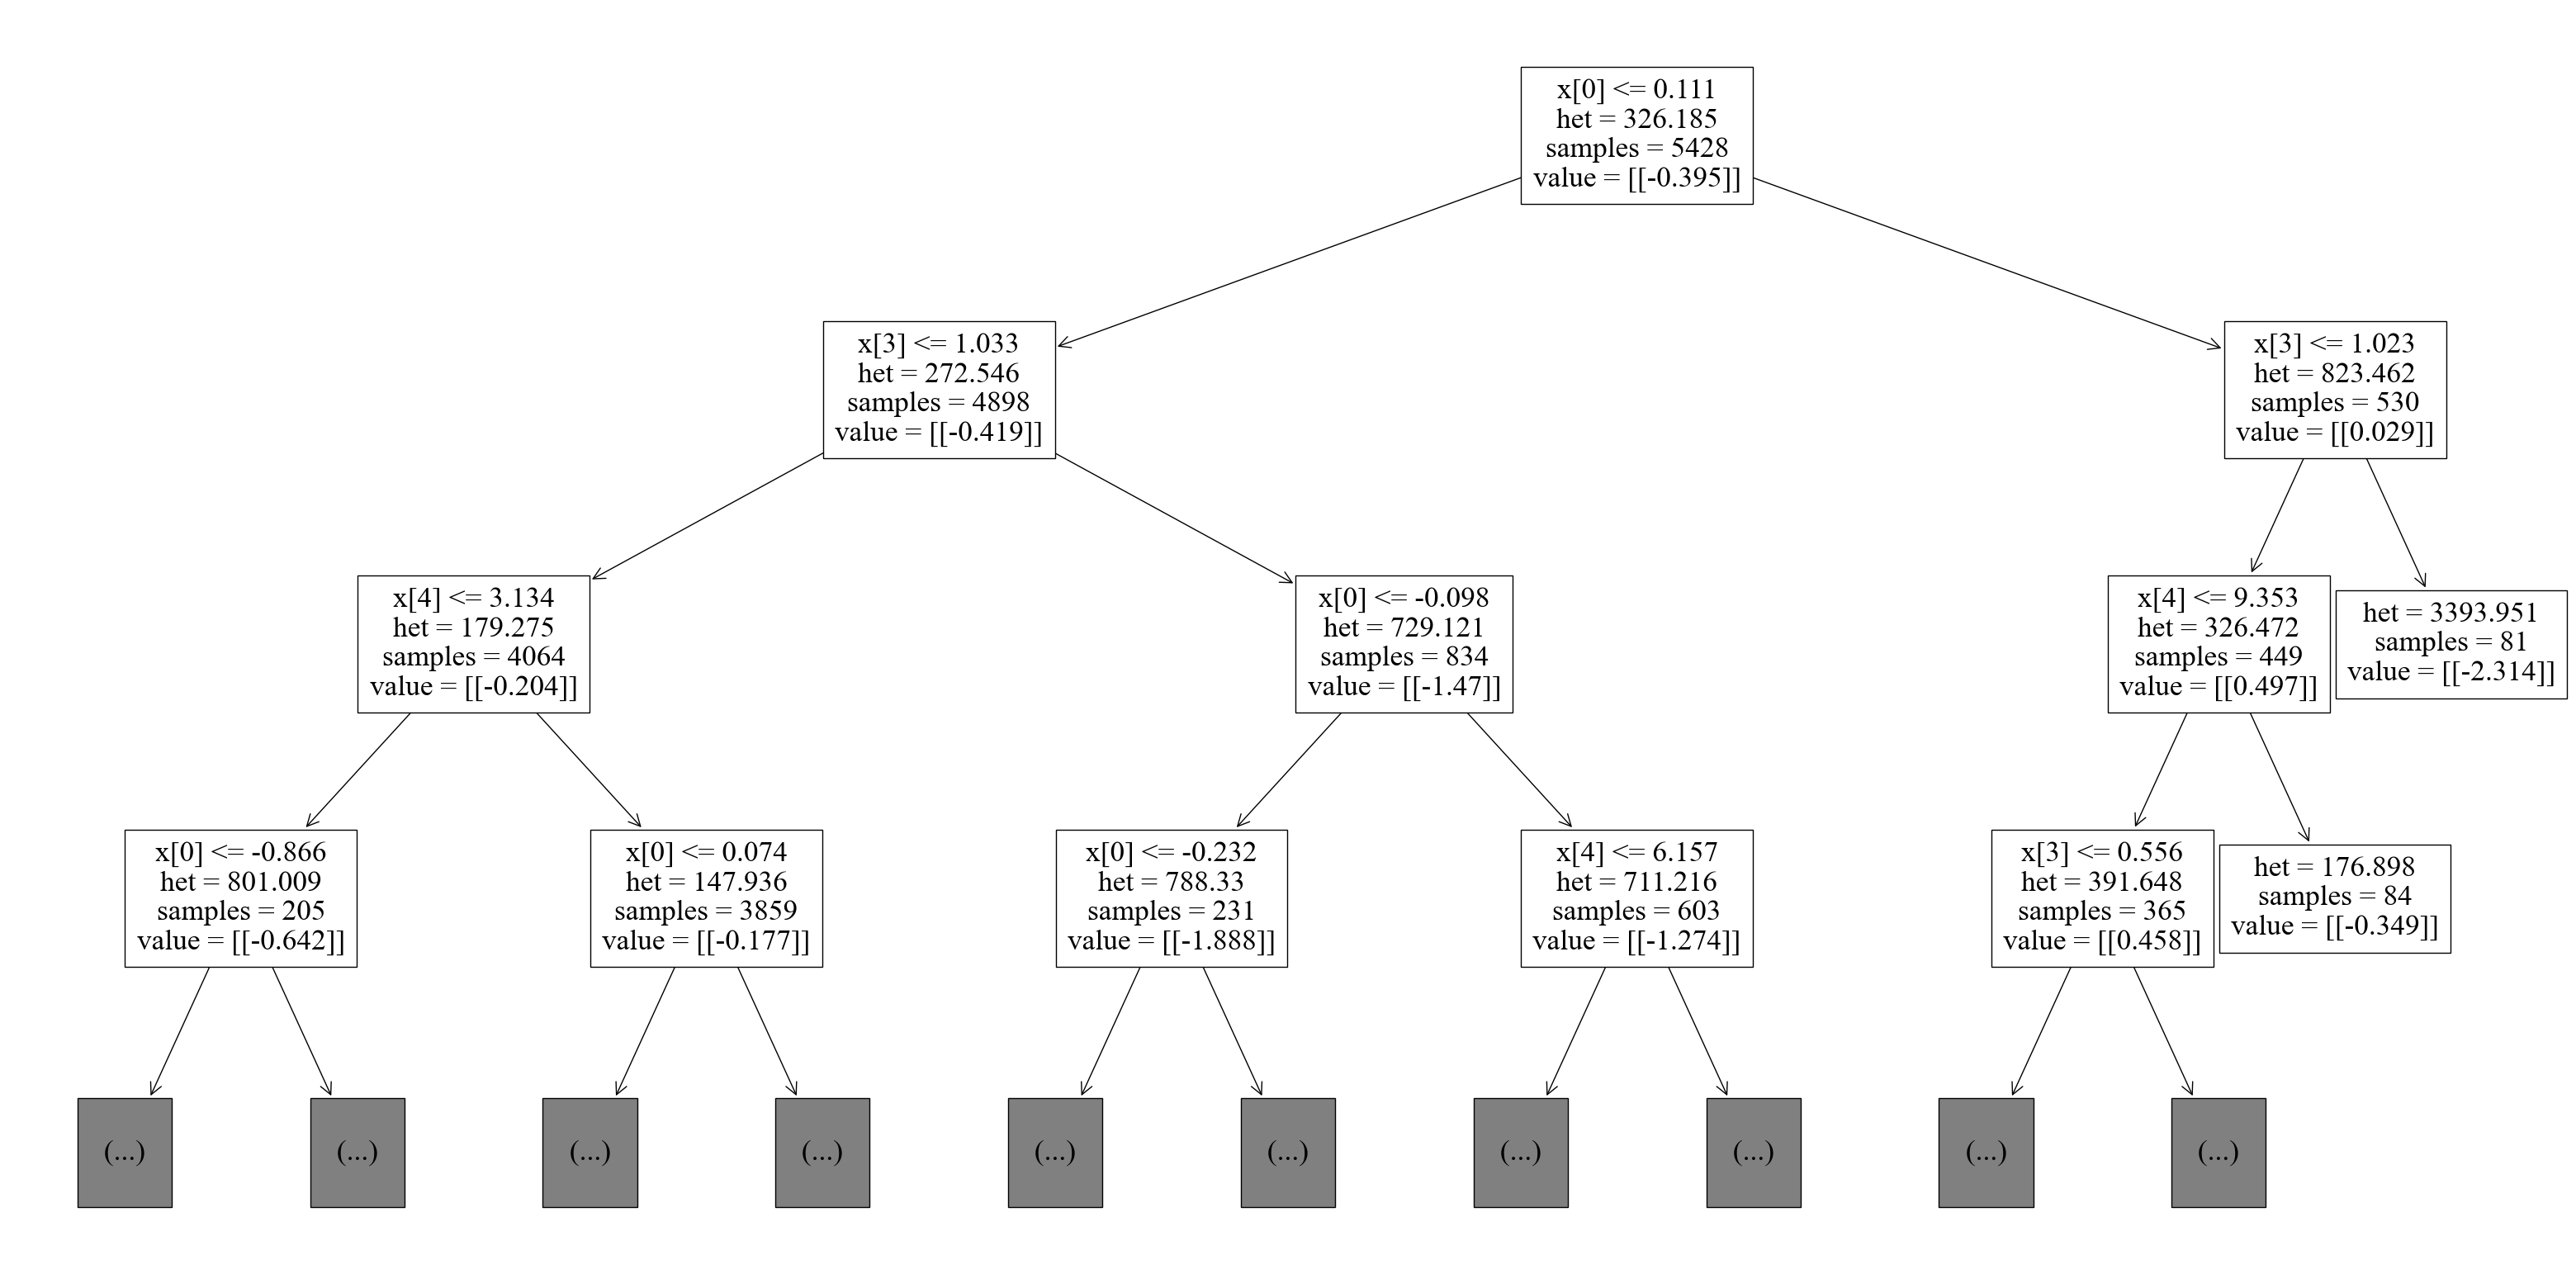

ATE: -0.1733
SE: 0.0035
95%confidentual: [-0.1801, -0.1665]


In [153]:
causal_data = filtered_data[['ROA', 'leverage', 'current_ratio', 'debt_to_equity',
                            'ln_at', 'growth', 'dividend_binary',
                            'l_derhedgl_binary', 'ln_tobins_q','mb']].dropna()


X = causal_data[['ROA', 'leverage', 'current_ratio', 'debt_to_equity', 
                 'ln_at', 'growth', 'dividend_binary']].values
T = causal_data['l_derhedgl_binary'].values
y = causal_data['mb'].values.reshape(-1, 1)

# setting CausalForest， min leaf is 50 to prevent over-fitting
est = CausalForest(criterion='het', n_estimators=2000, min_samples_leaf=50, max_depth=20,
                   min_var_fraction_leaf=None, min_var_leaf_on_val=True,
                    max_samples=0.45, min_balancedness_tol=.45,
                   warm_start=False, inference=True, fit_intercept=True, subforest_size=4,
                   honest=True, verbose=0, n_jobs=-1, random_state=1234)


est.fit(X, T, y)

plt.figure(figsize=(40, 20))
plot_tree(est[0], impurity=True,  max_depth=3)
plt.show()

individual_effects = est.predict(X)

ate = np.mean(individual_effects)
ate_se = np.std(individual_effects) / np.sqrt(len(individual_effects))
print(f"ATE: {ate:.4f}")
print(f"SE: {ate_se:.4f}")
print(f"95%confidentual: [{ate - 1.96*ate_se:.4f}, {ate + 1.96*ate_se:.4f}]")

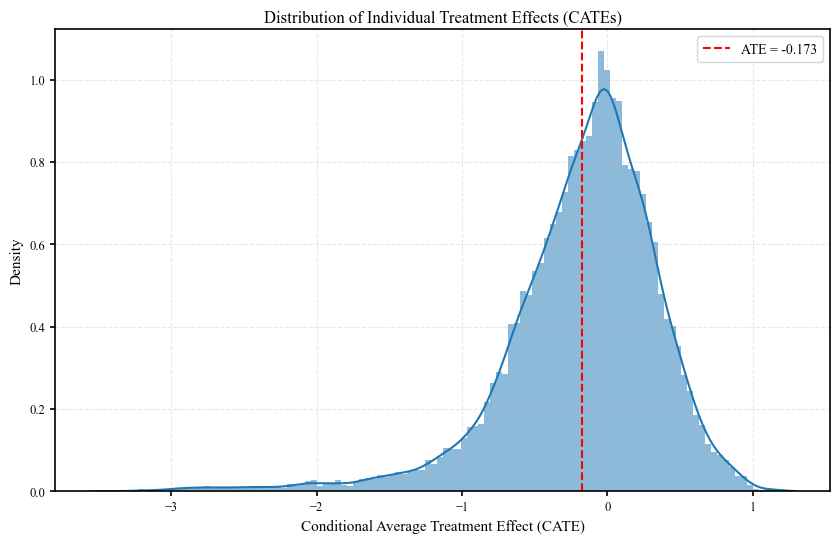

In [154]:
# \caption{Distribution of Individual Treatment Effects Derivatives Usage among Companies (2013-2023)} \label{fig:CATE_Kde_derhedgl}
cates = est.predict(X)
ate_value = np.mean(cates)
plt.figure(figsize=(10, 6))
sns.histplot(cates, kde=True, stat="density", linewidth=0)
plt.axvline(ate_value, color='red', linestyle='--', label=f'ATE = {ate_value:.3f}')
plt.xlabel('Conditional Average Treatment Effect (CATE)')
plt.ylabel('Density')
plt.title('Distribution of Individual Treatment Effects (CATEs)')
plt.legend()
plt.savefig('CATE_Kde_derhedgl.pdf', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()


1     ROA                  0.275      27.5    %
2     debt_to_equity       0.267      26.7    %
3     leverage             0.154      15.4    %
4     ln_at                0.123      12.3    %
5     current_ratio        0.118      11.8    %
6     growth               0.062      6.2     %
7     dividend_binary      0.000      0.0     %


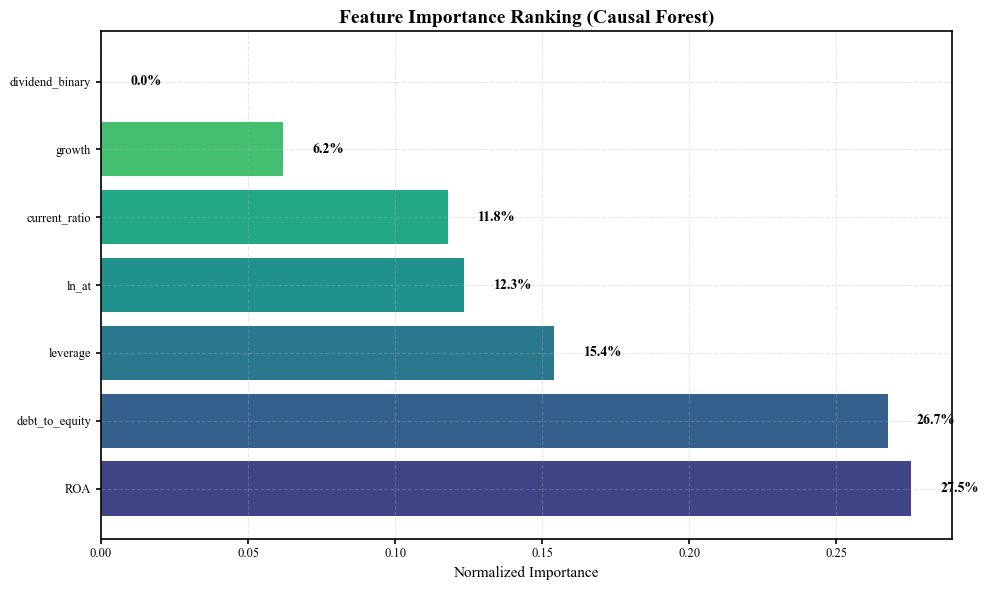


Results saved.csv


In [155]:
#\caption{Feature Importance Ranking: Contribution to Heterogeneity in Causal Forest Model(Derivative gain or loss )}
feature_names = ['ROA', 'leverage', 'current_ratio', 'debt_to_equity', 
                 'ln_at', 'growth', 'dividend_binary']


if hasattr(est, 'feature_importances_'):
    importance = est.feature_importances_
else:
    importance = np.ones(len(feature_names)) / len(feature_names)


if importance.sum() > 0:
    importance_norm = importance / importance.sum()


df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Score': importance,
    'Normalized': importance_norm,
    'Percentage': importance_norm * 100
})

df = df.sort_values('Normalized', ascending=False)
df['Rank'] = range(1, len(df) + 1)


for _, row in df.iterrows():
    print(f"{row['Rank']:<5} {row['Feature']:<20} {row['Normalized']:<10.3f} {row['Percentage']:<8.1f}%")

print("="*60)


plt.figure(figsize=(10, 6))
bars = plt.barh(df['Feature'], df['Normalized'], color=colors)
plt.xlabel('Normalized Importance')
plt.title('Feature Importance Ranking (Causal Forest)', fontsize=14, fontweight='bold')

for bar, value in zip(bars, df['Normalized']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{value:.1%}', va='center', fontweight='bold')

plt.grid(True, axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('feature_importance_ranking_mb.pdf',dpi=300, bbox_inches='tight', pad_inches=0.1 )
plt.show()


df.to_csv('feature_importance_mb.csv', index=False)
print("\nResults saved.csv")

In [158]:
ite = est.predict(X).flatten()

# Add ITE back to original data
df_analysis = causal_data.copy()
df_analysis['ITE'] = ite


# ============ 2. Select top 20% ITE companies ============
top_percent = 0.20   # can adjust to 0.10 or 0.30
threshold = np.quantile(ite, 1 - top_percent)

df_high_ite = df_analysis[df_analysis['ITE'] >= threshold]

print("Number of high-ITE companies:", len(df_high_ite))

# ============ 3. Summarize feature means ============
feature_cols = ['ROA', 'leverage', 'current_ratio', 'debt_to_equity']

high_ite_profile = df_high_ite[feature_cols].describe()
overall_profile = df_analysis[feature_cols].describe()

print("\n=== High-ITE Company Profile (Top 20%) ===")
print(high_ite_profile)

print("\n=== Overall Company Profile ===")
print(overall_profile)

# ============ 4. Compare difference ============
diff = high_ite_profile.loc['mean'] - overall_profile.loc['mean']
print("\n=== Difference Between High-ITE and Overall (means) ===")
print(diff.sort_values(ascending=False))


Number of high-ITE companies: 4825

=== High-ITE Company Profile (Top 20%) ===
               ROA     leverage  current_ratio  debt_to_equity
count  4825.000000  4825.000000    4825.000000     4825.000000
mean     -0.102453     0.333082       2.592286        0.186305
std       0.382020     0.306313       2.122063        1.264190
min      -2.002434     0.001292       0.112631       -5.418169
25%      -0.111844     0.150650       1.437527        0.129089
50%       0.031865     0.272984       1.999183        0.319894
75%       0.106523     0.399952       3.036595        0.560771
max       0.283978     1.549138      14.114077        8.445838

=== Overall Company Profile ===
                ROA      leverage  current_ratio  debt_to_equity
count  24125.000000  24125.000000   24125.000000    24125.000000
mean      -0.057850      0.344377       2.123879        0.631270
std        0.295799      0.261041       1.934199        1.379584
min       -2.002434      0.001292       0.112631       -5.418

In [159]:

from scipy.stats import ttest_ind

# \caption{T-Test Results: High ITE vs Overall Sample} \label{tab:t_test_results}

# feature list
feature_cols = ['ROA', 'leverage', 'current_ratio', 'debt_to_equity', 
                 'ln_at', 'growth', 'dividend_binary']

results = []

for col in feature_cols:
    high_group = df_high_ite[col].dropna()
    overall_group = df_analysis[col].dropna()

    # Welch’s t-test (unequal variance)
    t_stat, p_val = ttest_ind(high_group, overall_group, equal_var=False)

    # effect direction (mean difference)
    mean_diff = high_group.mean() - overall_group.mean()

    # significance stars
    if p_val < 0.01:
        sig = "***"
    elif p_val < 0.05:
        sig = "**"
    elif p_val < 0.1:
        sig = "*"
    else:
        sig = ""

    results.append({
        "feature": col,
        "mean_high_ITE": high_group.mean(),
        "mean_overall": overall_group.mean(),
        "mean_diff": mean_diff,
        "t_stat": t_stat,
        "p_value": p_val,
        "significance": sig
    })

# Convert to DataFrame
ttest_df = pd.DataFrame(results)
ttest_df = ttest_df.sort_values("mean_diff", ascending=False)


print("\n=== T-test Results: High ITE vs Overall ===")
print(ttest_df)





=== T-test Results: High ITE vs Overall ===
           feature  mean_high_ITE  mean_overall  mean_diff     t_stat  \
2    current_ratio       2.592286      2.123879   0.468407  14.198269   
6  dividend_binary       0.996062      0.996228  -0.000166  -0.168447   
1         leverage       0.333082      0.344377  -0.011295  -2.393325   
5           growth       0.033270      0.046997  -0.013727 -21.745773   
0              ROA      -0.102453     -0.057850  -0.044603  -7.663586   
3   debt_to_equity       0.186305      0.631270  -0.444965 -21.972050   
4            ln_at       6.446892      7.034185  -0.587293 -13.891314   

         p_value significance  
2   4.384797e-45          ***  
6   8.662366e-01               
1   1.672555e-02           **  
5  2.200190e-102          ***  
0   2.094080e-14          ***  
3  1.137537e-103          ***  
4   3.213421e-43          ***  


,costat,curcd,datafmt,indfmt,consol,tic,datadate,gvkey,dvpd,dvt,emp
0,A,USD,STD,INDL,C,AIR,2013-05-31,1004,NaN,11.9,6.30
1,A,USD,STD,INDL,C,AIR,2014-05-31,1004,NaN,11.8,5.80
2,A,USD,STD,INDL,C,AIR,2015-05-31,1004,NaN,11.9,4.85
3,A,USD,STD,INDL,C,AIR,2016-05-31,1004,NaN,10.4,4.70
4,A,USD,STD,INDL,C,AIR,2017-05-31,1004,NaN,10.2,4.60


In [53]:
old_data = pd.read_csv('filtered_data.csv')
new_data = pd.read_csv('ratios_data.csv')
new_data.head()

,gvkey,adate,qdate,public_date,npm,capital_ratio,ocf_lct,fcf_ocf,ptb
0,1004,2012-05-31,2012-11-30,2013-01-31,0.032,0.426,0.320,0.632,0.727
1,1004,2012-05-31,2012-11-30,2013-02-28,0.032,0.426,0.320,0.632,0.678
2,1004,2012-05-31,2012-11-30,2013-03-31,0.032,0.426,0.320,0.632,0.710
3,1004,2012-05-31,2013-02-28,2013-04-30,0.031,0.432,0.392,0.680,0.654
4,1004,2012-05-31,2013-02-28,2013-05-31,0.031,0.432,0.392,0.680,0.734


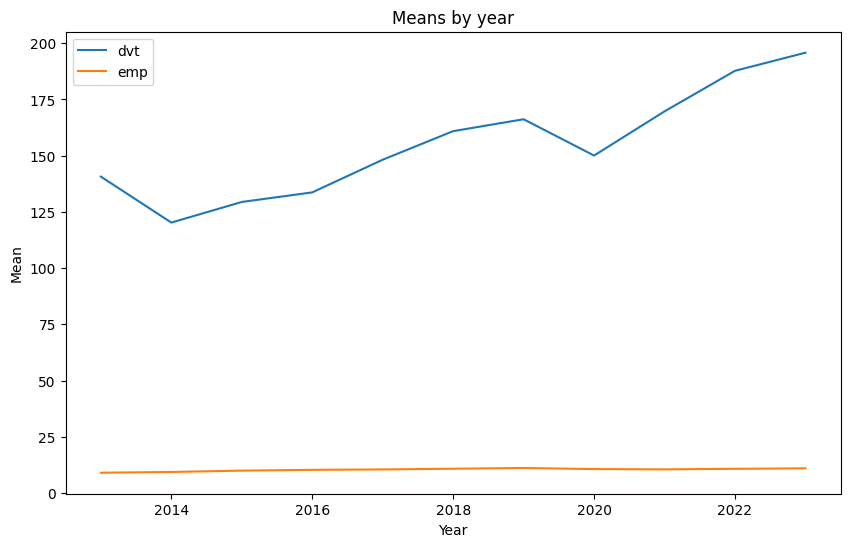

In [10]:
mean_by_year = new_data.groupby('fyear').mean(numeric_only=True)
mean_by_year.describe()
mean_by_year[['dvt','emp']].plot(figsize=(10,6))
plt.title('Means by year')
plt.ylabel('Mean')
plt.xlabel('Year')
plt.show()